# Individual Assignment- Computational Data Analytics with Python

### Real World Problem
#### Do countries with lower Gender Inequality Index (GII) tend to achieve higher Human Development Index (HDI)?

In [43]:
import pandas as pd          # library for data handling
import numpy as np           # library for numerical operations
import matplotlib.pyplot as plt   # library for charts

#Datasets were gotten from kaggle


## Data Loading (Code)

In [44]:
GenderInequalityIndex_dataframe = pd.read_csv("Gender Inequality Index.csv")   # load GII dataset
humanDevelopmentIndex_dataframe = pd.read_csv("hdr_general.csv", encoding="latin1")   # load HDI dataset

#AI Usage Here
#The file was not encoded in UTF-8, so pandas raised a UnicodeDecodeError.
#I resolved this by explicitly specifying a compatible encoding such as latin1 when loading the file


### Datasets 

#### Gender Inequality Index Dataset:
###### This dataset contains country-level indicators measuring gender inequality,including the Gender Inequality Index (GII), country rankings, and related demographic and regional classifications.

##### Human Development Index Dataset:
###### This dataset contains country-level development indicators such as the Human Development Index (HDI), life expectancy, education measures,and income per capita, which reflect overall human development outcomes.


## Data Preparation (Inspection)

In [45]:
GenderInequalityIndex_dataframe.info()   # check structure and data types
humanDevelopmentIndex_dataframe.info()   # check structure and data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ISO3                            195 non-null    object 
 1   Country                         195 non-null    object 
 2   Continent                       195 non-null    object 
 3   Hemisphere                      195 non-null    object 
 4   Human Development Groups        191 non-null    object 
 5   UNDP Developing Regions         151 non-null    object 
 6   HDI Rank (2021)                 191 non-null    float64
 7   GII Rank (2021)                 170 non-null    float64
 8   Gender Inequality Index (1990)  128 non-null    float64
 9   Gender Inequality Index (1991)  128 non-null    float64
 10  Gender Inequality Index (1992)  128 non-null    float64
 11  Gender Inequality Index (1993)  128 non-null    float64
 12  Gender Inequality Index (1994)  128 

In [46]:
GenderInequalityIndex_dataframe.head()   # preview first rows


,ISO3,Country,Continent,Hemisphere,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),GII Rank (2021),Gender Inequality Index (1990),Gender Inequality Index (1991),...,Gender Inequality Index (2012),Gender Inequality Index (2013),Gender Inequality Index (2014),Gender Inequality Index (2015),Gender Inequality Index (2016),Gender Inequality Index (2017),Gender Inequality Index (2018),Gender Inequality Index (2019),Gender Inequality Index (2020),Gender Inequality Index (2021)
0,AFG,Afghanistan,Asia,Northern Hemisphere,Low,SA,180.0,167.0,NaN,NaN,...,0.738,0.728,0.718,0.706,0.692,0.678,0.671,0.665,0.674,0.678
1,AGO,Angola,Africa,Southern Hemisphere,Medium,SSA,148.0,136.0,0.725,0.723,...,0.545,0.540,0.531,0.530,0.529,0.538,0.537,0.537,0.537,0.537
2,ALB,Albania,Europe,Northern Hemisphere,High,ECA,67.0,39.0,NaN,NaN,...,0.235,0.225,0.219,0.204,0.191,0.170,0.164,0.156,0.156,0.144
3,AND,Andorra,Europe,Northern Hemisphere,Very High,NaN,40.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Asia,Northern Hemisphere,Very High,AS,26.0,11.0,0.659,0.647,...,0.171,0.161,0.151,0.126,0.118,0.112,0.103,0.056,0.050,0.049


In [47]:
humanDevelopmentIndex_dataframe.head()   # preview first rows

,Unnamed: 0,iso3,country,hdicode,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,Low,182.0,162.0,1990,0.284,45.967,10.694796,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,Low,182.0,162.0,1991,0.292,46.663,10.745167,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,Low,182.0,162.0,1992,0.299,47.596,12.057433,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,Low,182.0,162.0,1993,0.307,51.466,14.003760,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,Low,182.0,162.0,1994,0.300,51.495,15.455554,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


## Data Cleaning & EDA

In [48]:
GenderInequalityIndex_dataframe["iso3"] = GenderInequalityIndex_dataframe["ISO3"].str.strip().str.upper()  # standardise country code
humanDevelopmentIndex_dataframe["iso3"] = humanDevelopmentIndex_dataframe["iso3"].str.strip().str.upper()  # standardise country code


In [49]:
GenderInequalityIndex_clean = GenderInequalityIndex_dataframe[["iso3","Country","Gender Inequality Index (2021)"]] \
.rename(columns={"Country":"country_GII","Gender Inequality Index (2021)":"GenderInequalityIndex_2021"})   # keep relevant columns

HumanDevelopmentIndex_2022 = humanDevelopmentIndex_dataframe[humanDevelopmentIndex_dataframe["year"]==2022] \ #Create a new datasframe
[["iso3","country","year","hdi","life_expectancy","gross_inc_percap"]]   # Filtering the dataset to only select HDI year 2022 data

HumanDevelopmentIndex_2022 = HumanDevelopmentIndex_2022.rename(columns={"hdi":"HumanDevelopmentIndex"})   # rename HDI column


In [50]:
GenderInequalityIndex_clean.duplicated(subset=["iso3"]).sum()   # check duplicate countries in GII
HumanDevelopmentIndex_2022.duplicated(subset=["iso3"]).sum()   # check duplicate countries in HDI


np.int64(0)

In [51]:
# missing-value check
GenderInequalityIndex_clean.isna().sum(), HumanDevelopmentIndex_2022.isna().sum()

(iso3                           0
 country_GII                    0
 GenderInequalityIndex_2021    25
 dtype: int64,
 iso3                     0
 country                  0
 year                     0
 HumanDevelopmentIndex    2
 life_expectancy          0
 gross_inc_percap         2
 dtype: int64)

In [52]:
print("Gender Inequality Index 2021 summary:")
print(GenderInequalityIndex_clean["GenderInequalityIndex_2021"].describe())

Gender Inequality Index 2021 summary:
count    170.000000
mean       0.344376
std        0.197105
min        0.013000
25%        0.177500
50%        0.363000
75%        0.505750
max        0.820000
Name: GenderInequalityIndex_2021, dtype: float64


## Join Datasets

In [53]:
master_dataframe = HumanDevelopmentIndex_2022.merge(   # join HDI dataset
    GenderInequalityIndex_clean,                # with GII dataset
    on="iso3",                                  # match using ISO country code
    how="inner"                                 # keep only matching countries
)

master_dataframe = master_dataframe.dropna(subset=["GenderInequalityIndex_2021","HumanDevelopmentIndex"])   # remove missing values

# ---- Clean join key (ISO3) ----
# Why?: ISO3 codes are more reliable than country names for joining
# Select the GII year that matches best with HDI year availability 
# Compare Gender Inequality Index (2021) with Human Development Index (2022)
# Gender Inequality Index (2021) was compared with Human Development Index (2022)
# because 2021 is the most recent year available in the inequality dataset and 2022
# is the closest available year in the development dataset, allowing a near-time comparison.


##### Join explanation:
##### The datasets were merged to combine Gender Inequality Index and Human Development Index information into a single dataset for analysis. 
##### An inner join was used based on the ISO3 country code to retain only countries present in both datasets, enabling examination of the relationship between gender inequality and human development and identification of countries that deviate from the expected pattern.


In [54]:
master_dataframe.head()      # shows first 5 rows of the joined dataset


,iso3,country,year,HumanDevelopmentIndex,life_expectancy,gross_inc_percap,country_GII,GenderInequalityIndex_2021
0,AFG,Afghanistan,2022,0.462,62.879,1335.205733,Afghanistan,0.678
1,ALB,Albania,2022,0.789,76.833,15293.326510,Albania,0.144
2,DZA,Algeria,2022,0.745,77.129,10978.405710,Algeria,0.499
4,AGO,Angola,2022,0.591,61.929,5327.788251,Angola,0.537
6,ARG,Argentina,2022,0.849,76.064,22047.971310,Argentina,0.287


In [55]:
master_dataframe.shape

(170, 8)

In [72]:
print(master_dataframe.columns)

Index(['iso3', 'country', 'year', 'HumanDevelopmentIndex', 'life_expectancy',
       'gross_inc_percap', 'country_GII', 'GenderInequalityIndex_2021',
       'HumanDevelopmentIndex_predicted', 'residual',
       'GenderInequalityIndex_quartile'],
      dtype='object')


## DATA ANALYSIS
## Correlation + Simple Linear Regression + Outliers

In [57]:
# ---- Correlation (Pearson) ----#

correlation_value = master_dataframe["GenderInequalityIndex_2021"].corr(master_dataframe["HumanDevelopmentIndex"])   # calculate Pearson correlation
print("Pearson correlation:", round(correlation_value, 3))   # display result


Pearson correlation: -0.911


##### Interpretation:
##### The Pearson correlation between Gender Inequality Index (2021) and Human Development Index (2022) is -0.911.
##### This indicates a very strong negative relationship, meaning that countries with higher gender inequality
##### tend to have lower levels of human development.
##### Although this shows a strong association, it does not imply causation, as other factors such as income,
##### education, and healthcare systems may also influence human development outcomes.


In [73]:
# ---- Simple Linear Regression ----#

x = master_dataframe["GenderInequalityIndex_2021"].values   # select inequality column and convert to NumPy array (independent variable)
y = master_dataframe["HumanDevelopmentIndex"].values         # select HDI column and convert to NumPy array (dependent variable)

slope, intercept = np.polyfit(x, y, 1)   # apply NumPy polyfit function (linear regression, degree=1) returning slope and intercept

master_dataframe["HumanDevelopmentIndex_predicted"] = intercept + slope * master_dataframe["GenderInequalityIndex_2021"]   # create new column with predicted HDI using regression equation

master_dataframe["residual"] = master_dataframe["HumanDevelopmentIndex"] - master_dataframe["HumanDevelopmentIndex_predicted"]   # compute residuals (actual minus predicted values)

print("\nRegression: HumanDevelopmentIndex =", round(intercept, 3), "+", round(slope, 3), "* GenderInequalityIndex_2021")   # print formatted regression equation rounded to 3 decimals



Regression: HumanDevelopmentIndex = 0.975 + -0.723 * GenderInequalityIndex_2021


##### Interpretation:
##### The regression coefficient (-0.723) indicates a negative relationship between Gender Inequality Index
##### and Human Development Index. This means that as gender inequality increases, human development tends to
##### decrease.


## GROUPING + AGGREGATION

In [70]:
# Create inequality groups (quartiles) based on Gender Inequality Index values

master_dataframe["GenderInequalityIndex_quartile"] = pd.qcut(
    master_dataframe["GenderInequalityIndex_2021"],   # column used to create groups
    q=4,                                              # divide data into 4 equal-sized groups
    labels=["Lowest Inequality", "Low-Mid Inequality", "High-Mid Inequality", "Highest Inequality"]   # assign group names
)


# Group countries by inequality quartile and compute summary statistics
quartile_summary = (
    master_dataframe.groupby("GenderInequalityIndex_quartile", observed=True)   # group rows by quartile category
    .agg(
        Average_HumanDevelopmentIndex=("HumanDevelopmentIndex", "mean"),   # compute average HDI for each group
        Average_LifeExpectancy=("life_expectancy", "mean"),                # compute average life expectancy
        Average_IncomePerCapita=("gross_inc_percap", "mean"),              # compute average income per capita
        Countries=("country", lambda x: ", ".join(sorted(x)))              # list countries belonging to each group
    )
    .sort_index()   # order the groups from lowest to highest inequality
)

quartile_summary   # display the summary table




,Average_HumanDevelopmentIndex,Average_LifeExpectancy,Average_IncomePerCapita,Countries
GenderInequalityIndex_quartile,,,,
Lowest Inequality,0.899326,80.294651,44657.944323,"Albania, Australia, Austria, Belarus, Belgium,..."
Low-Mid Inequality,0.795714,75.095286,25184.378441,"Argentina, Armenia, Azerbaijan, Bahamas, Bahra..."
High-Mid Inequality,0.684000,70.425333,10284.313197,"Algeria, Belize, Bhutan, Bolivia (Plurinationa..."
Highest Inequality,0.524651,62.108023,3349.012538,"Afghanistan, Angola, Bangladesh, Benin, Burkin..."


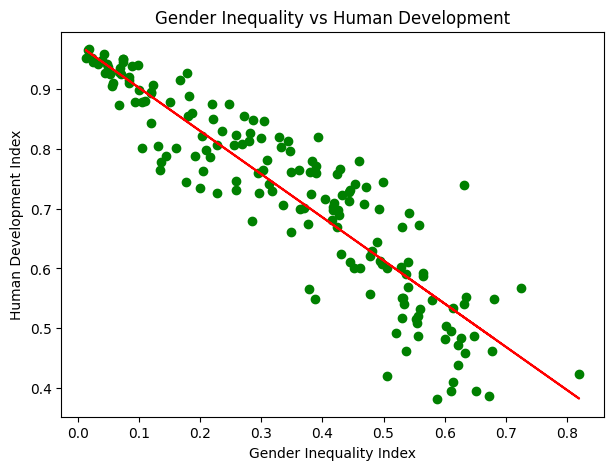

In [62]:
#Gender Inequality vs Human Development

plt.figure(figsize=(7,5))   # create chart size
plt.scatter(master_dataframe["GenderInequalityIndex_2021"], master_dataframe["HumanDevelopmentIndex"], color="green")   # scatter points
plt.plot(master_dataframe["GenderInequalityIndex_2021"], intercept + slope*master_dataframe["GenderInequalityIndex_2021"], color="red")   # regression line
plt.xlabel("Gender Inequality Index")   # x-axis label
plt.ylabel("Human Development Index")   # y-axis label
plt.title("Gender Inequality vs Human Development")   # title
plt.show()   # display chart


### Insight:
##### The scatter plot shows a clear downward trend, indicating that countries with higher Gender Inequality Index values generally have lower Human Development Index levels.
#### This visual supports the strong negative correlation observed in the analysis.


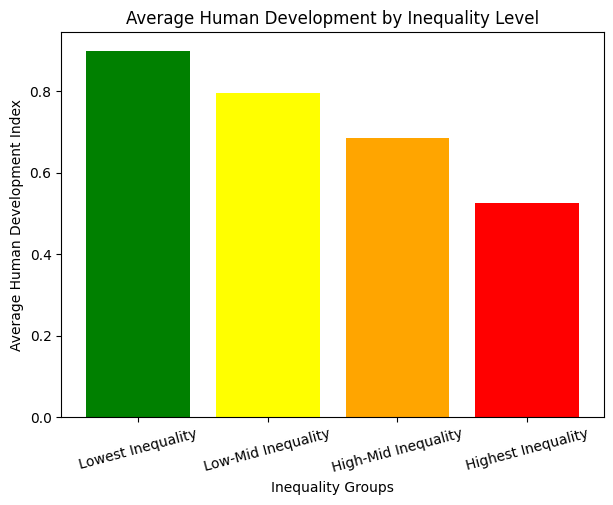

In [68]:
#Average Human Development by Inequality level

plt.figure(figsize=(7,5))   # create chart
colors = ["green","yellow","orange","red"]   # assign colours

plt.bar(quartile_summary.index.astype(str),
quartile_summary["Average_HumanDevelopmentIndex"],
color=colors)   # create bar chart

plt.xlabel("Inequality Groups")   # x label
plt.ylabel("Average Human Development Index")   # y label
plt.title("Average Human Development by Inequality Level")   # title
plt.xticks(rotation=15)  #Rotate
plt.show()   # display chart


### Insight:
##### The bar chart shows that countries in the lowest inequality quartile have the highest average Human Development Index, while countries in the highest inequality quartile have the lowest development levels, highlighting the development gap across inequality groups.


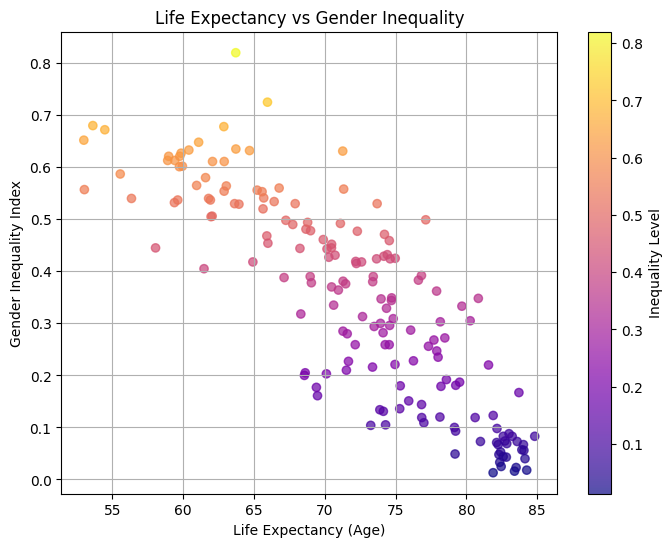

In [71]:
#Life Expectancy VS Gender Inequality 

plt.figure(figsize=(8,6))         # Create a new figure and set chart size

plt.scatter(
    master_dataframe["life_expectancy"],                # X-axis: Life expectancy (age)
    master_dataframe["GenderInequalityIndex_2021"],    # Y-axis: Gender inequality index
    c=master_dataframe["GenderInequalityIndex_2021"],  # Colour points based on inequality values
    cmap="plasma",                              # Use colourful gradient palette
    alpha=0.7                                   # Add transparency for clearer viewing
)

plt.xlabel("Life Expectancy (Age)")             # Label the X-axis
plt.ylabel("Gender Inequality Index")           # Label the Y-axis
plt.title("Life Expectancy vs Gender Inequality")  # Add chart title

plt.colorbar(label="Inequality Level")          # Add colour legend explaining colour scale
plt.grid(True)                                  # Add gridlines to make values easier to read
plt.show()                                      # Display the chart

### Insight:
##### The regression line illustrates the overall negative relationship between gender inequality and human development. Countries positioned far from the line represent outliers that perform either better or worse than expected based on their inequality levels.
##### It also shows that countries with lower inequality level have higher life expectancy

## Key Insights from the Analysis:
#### The results show a strong negative relationship (correlation = -0.911) between Gender Inequality and Human Development, indicating that countries with lower gender inequality generally achieve higher human development outcomes. 
#### The regression analysis confirms this pattern, showing that increases in gender inequality are associated with decreases in the Human Development Index.
#### Quartile comparisons further reveal that countries in the lowest inequality group have the highest average development levels, while countries in the highest inequality group show lower development outcomes. 


### Business Interpretation:
#### The findings suggest that countries with lower gender inequality tend to achieve stronger development outcomes, which may indicate more inclusive labour markets, better education access, and improved economic productivity. 
#### For policymakers, this highlights the importance of gender-equality initiatives as part of long-term development strategies. For businesses and ESG investors, countries with lower inequality may represent more stable and sustainable environments for investment, while countries with higher inequality may require targeted social investment and development-focused programs.


## Responsible AI Usage 

#### AI was used to assist with structuring the analysis workflow and Generating code.

#### AI was used in resloving errors. 

#### All column names, joins, and outputs were verified manually by me.

#### AI used short forms for the dataframe name which might be confusing for understanding , so i changed them to readable names E.g GII.df was changed to Genderinequalityindex.Dataframe.

#### AI Prompt

#### I am interested in Gender Inequality and i have found a dataset on Kaggle, I will like to know how it effects a country's Human development index, If truely gender Inequality creates an impact in the country. kindly generate a code for correlation , and simple linear regression. Make the code as simple as possible for simple understanding.kindly give me a workflow for this analysis. 

#### While trying to load my dataset i encountered an error , kindly help me check what is wrong.